In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

In [1]:
import os
import json

os.makedirs('/root/.kaggle', exist_ok=True)

kaggle_json = {
    "username": "itxminoo",
    "key": "KGAT_4c9b6753aeb313fd7be04409838e5992"
}

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_json, f)

os.chmod('/root/.kaggle/kaggle.json', 600)
print("Kaggle configured ✅")

Kaggle configured ✅


In [2]:
!kaggle datasets download -d sovitrath/diabetic-retinopathy-224x224-gaussian-filtered
print("Downloaded ✅")

Dataset URL: https://www.kaggle.com/datasets/sovitrath/diabetic-retinopathy-224x224-gaussian-filtered
License(s): CC0-1.0
100% 427M/427M [00:07<00:00, 63.8MB/s]

Downloaded ✅


In [3]:
import zipfile

print("Extracting... ⏳")
with zipfile.ZipFile('diabetic-retinopathy-224x224-gaussian-filtered.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dr_dataset')
print("Extracted ✅")

# Explore structure
import os
for root, dirs, files in os.walk('/content/dr_dataset'):
    level = root.replace('/content/dr_dataset', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3 and files:
        print(f'{indent}  ({len(files)} files)')

Extracting... ⏳
Extracted ✅
dr_dataset/
  (1 files)
  gaussian_filtered_images/
    gaussian_filtered_images/
      (1 files)
      No_DR/
      Severe/
      Proliferate_DR/
      Mild/
      Moderate/


In [4]:
import os

base_path = '/content/dr_dataset/gaussian_filtered_images/gaussian_filtered_images'

classes = ['No_DR', 'Mild', 'Moderate', 'Severe', 'Proliferate_DR']

for class_name in classes:
    class_path = os.path.join(base_path, class_name)
    count = len(os.listdir(class_path))
    print(f"{class_name}: {count} images")

No_DR: 1805 images
Mild: 370 images
Moderate: 999 images
Severe: 193 images
Proliferate_DR: 295 images


In [5]:
import cv2
import numpy as np

IMG_SIZE = 150
LIMIT_PER_CLASS = 400  # Balance the dataset

def load_dr_images(base_path, classes, limit=None):
    images = []
    labels = []

    for class_name in classes:
        class_path = os.path.join(base_path, class_name)
        files = os.listdir(class_path)
        if limit:
            files = files[:limit]

        # Binary label: 0 = No_DR, 1 = Has DR
        label = 0 if class_name == 'No_DR' else 1

        for i, filename in enumerate(files):
            img_path = os.path.join(class_path, filename)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                images.append(img)
                labels.append(label)

        print(f"{class_name}: {len(files)} loaded ✅")

    return np.array(images), np.array(labels)

classes = ['No_DR', 'Mild', 'Moderate', 'Severe', 'Proliferate_DR']

print("Loading images... ⏳")
X, y = load_dr_images(base_path, classes, limit=LIMIT_PER_CLASS)

print(f"\nTotal images: {len(X)}")
print(f"No DR: {(y==0).sum()}")
print(f"Has DR: {(y==1).sum()}")

Loading images... ⏳
No_DR: 400 loaded ✅
Mild: 370 loaded ✅
Moderate: 400 loaded ✅
Severe: 193 loaded ✅
Proliferate_DR: 295 loaded ✅

Total images: 1658
No DR: 400
Has DR: 1258


In [6]:
from sklearn.model_selection import train_test_split

X = X.astype('float32') / 255.0

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Train - No DR: {(y_train==0).sum()}, Has DR: {(y_train==1).sum()}")
print(f"Test - No DR: {(y_test==0).sum()}, Has DR: {(y_test==1).sum()}")

Train: 1326 | Test: 332
Train - No DR: 320, Has DR: 1006
Test - No DR: 80, Has DR: 252


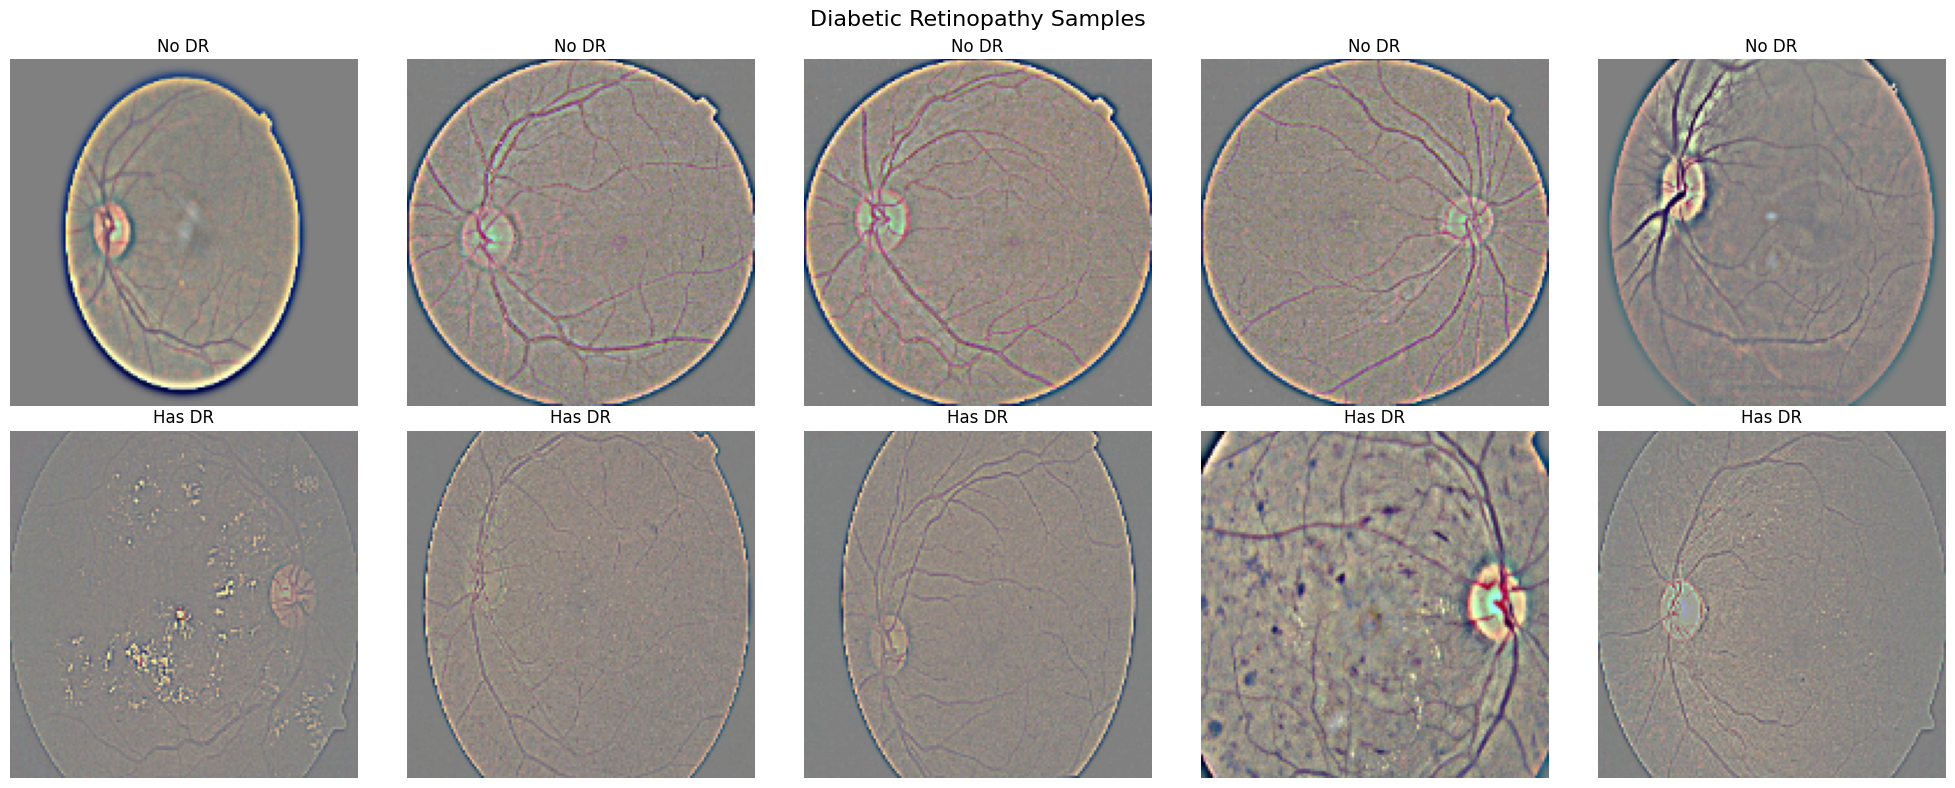

Saved! ✅


In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

no_dr_idx = np.where(y_train==0)[0][:5]
has_dr_idx = np.where(y_train==1)[0][:5]

for i, idx in enumerate(no_dr_idx):
    axes[0, i].imshow(X_train[idx])
    axes[0, i].set_title('No DR')
    axes[0, i].axis('off')

for i, idx in enumerate(has_dr_idx):
    axes[1, i].imshow(X_train[idx])
    axes[1, i].set_title('Has DR')
    axes[1, i].axis('off')

plt.suptitle('Diabetic Retinopathy Samples', fontsize=16)
plt.tight_layout()
plt.savefig('dr_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved! ✅")

In [9]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print(f"TensorFlow version: {tf.__version__}")
print("Imports done ✅")

TensorFlow version: 2.20.0
Imports done ✅


In [10]:
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam

tf.keras.backend.clear_session()

def build_dr_cnn(input_shape=(150, 150, 3)):
    model = tf.keras.Sequential([
        layers.Conv2D(32, (3,3), activation='relu',
                     input_shape=input_shape, padding='same'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

model = build_dr_cnn()
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()
print("CNN built ✅")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

CNN built ✅


In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen.fit(X_train)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=8, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        factor=0.5, patience=4, verbose=1, min_lr=1e-6)
]

print("Training started... ⏳")
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_test, y_test),
    epochs=25,
    callbacks=callbacks
)
print("Training complete! ✅")

Training started... ⏳
Epoch 1/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 19s 292ms/step - accuracy: 0.7572 - loss: 0.5799 - val_accuracy: 0.7590 - val_loss: 0.5584 - learning_rate: 0.0010
Epoch 2/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 157ms/step - accuracy: 0.7587 - loss: 0.5595 - val_accuracy: 0.7590 - val_loss: 0.5092 - learning_rate: 0.0010
Epoch 3/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 8s 184ms/step - accuracy: 0.7602 - loss: 0.5293 - val_accuracy: 0.8705 - val_loss: 0.4197 - learning_rate: 0.0010
Epoch 4/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 160ms/step - accuracy: 0.8446 - loss: 0.3899 - val_accuracy: 0.9307 - val_loss: 0.2789 - learning_rate: 0.0010
Epoch 5/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 8s 184ms/step - accuracy: 0.8665 - loss: 0.3704 - val_accuracy: 0.7831 - val_loss: 0.4878 - learning_rate: 0.0010
Epoch 6/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 170ms/step - accuracy: 0.8703 - loss: 0.3666 - val_accuracy: 0.9217 - val_loss: 0.3273 - learning_rate: 0.0010
Epoch 7/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 166ms/step - accuracy: 0

In [12]:
results = model.evaluate(X_test, y_test, verbose=1)
print("\n" + "="*40)
print("🎯 FINAL MODEL RESULTS")
print("="*40)
print(f"Test Loss:     {results[0]:.4f}")
print(f"Test Accuracy: {results[1]*100:.2f}%")
print("="*40)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9277 - loss: 0.2695

🎯 FINAL MODEL RESULTS
Test Loss:     0.2695
Test Accuracy: 92.77%


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step
              precision    recall  f1-score   support

       No DR       0.81      0.91      0.86        80
      Has DR       0.97      0.93      0.95       252

    accuracy                           0.93       332
   macro avg       0.89      0.92      0.91       332
weighted avg       0.93      0.93      0.93       332



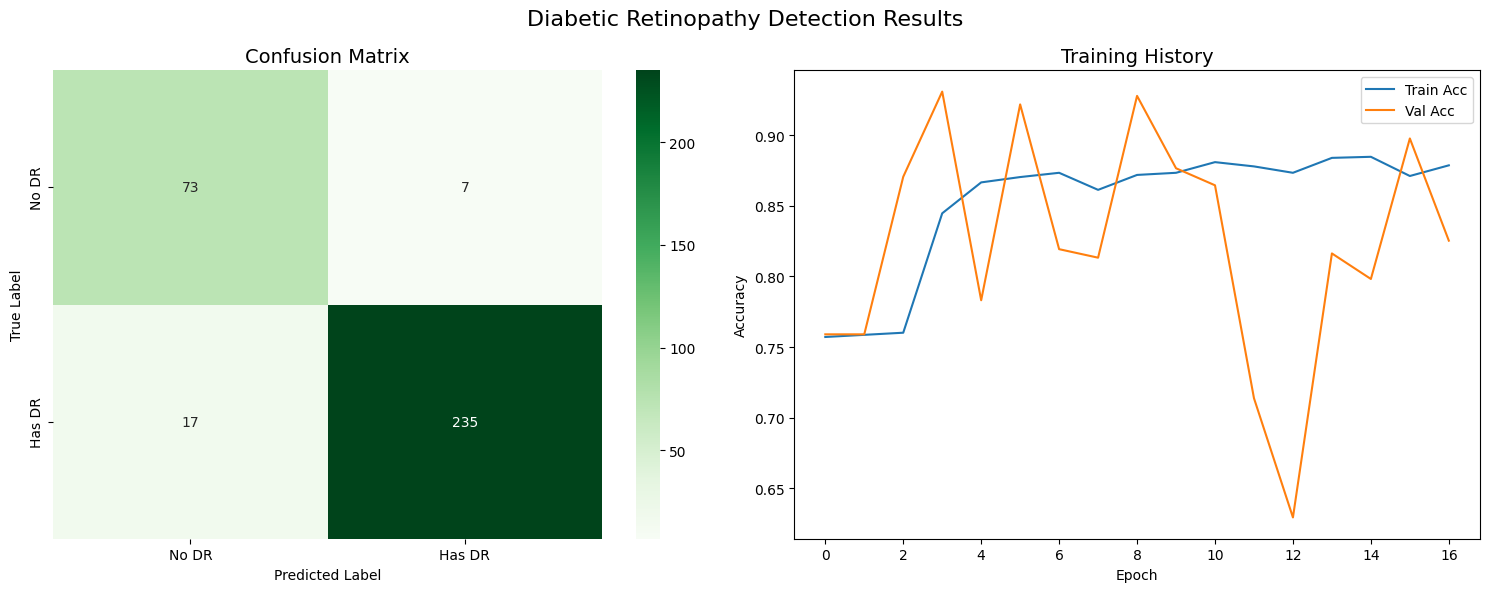

Results saved! ✅


In [13]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print(classification_report(y_test, y_pred,
    target_names=['No DR', 'Has DR']))

cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(cm, annot=True, fmt='d', ax=axes[0],
    cmap='Greens',
    xticklabels=['No DR', 'Has DR'],
    yticklabels=['No DR', 'Has DR'])
axes[0].set_title('Confusion Matrix', fontsize=14)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

axes[1].plot(history.history['accuracy'], label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('Training History', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Diabetic Retinopathy Detection Results', fontsize=16)
plt.tight_layout()
plt.savefig('dr_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Results saved! ✅")

In [14]:
# Save model
model.save('dr_model.h5')
print("✅ Model saved")

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open('dr_model.tflite', 'wb') as f:
    f.write(tflite_model)

print(f"✅ TFLite size: {len(tflite_model)/1024/1024:.2f} MB")

✅ Model saved
Saved artifact at '/tmp/tmpwfr9q_93'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135219358953744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135219358954512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135219358956624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135219358955280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135219358956048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135219358957200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135219358954128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135219358957008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135219358956432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135219358384976: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ 

In [15]:
from google.colab import files

files.download('dr_samples.png')
files.download('dr_results.png')
files.download('dr_model.tflite')
print("All downloaded! ✅")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All downloaded! ✅
